### Build A Basic Chatbot With Langraph(GRAPH API)

In [1]:
 from typing import Annotated
 from typing_extensions import TypedDict
 from langgraph.graph import StateGraph,START,END
 from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "List", The "add_messages" function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder=StateGraph(State)    

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [16]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="qwen/qwen3.6-27b")

In [17]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002418AF26C60>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002418AF27440>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [19]:
llm = init_chat_model(
    model="qwen/qwen3.6-27b",
    model_provider="groq",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002418BF4C8F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002418BF4E930>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [20]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [21]:
graph_builder = StateGraph(State)

# Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()


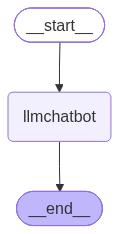

In [22]:
## visulaize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass    



In [28]:
response=graph.invoke({"messages":"Hi"})

In [29]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Internal):** Hello! How can I assist you today? Whether you have a question, need help with something, or just want to chat, I\'m here for you. 😊\n5.  **Refine Response:** Keep it concise, friendly, and professional. Match the tone of the greeting.\n   "Hi there! How can I help you today?" is simple and effective.\n6.  **Final Output Generation:** (Matches the refined version)✅\n</think>\n\nHi there! How can I help you today? 😊'

In [33]:
from langchain_core.messages import HumanMessage

for event in graph.stream(
    {"messages": [HumanMessage(content="Hi, How are you?")]}
):
    for value in event.values():
        last_message = value["messages"][-1]
        print(last_message.content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hi, How are you?"
   - This is a standard greeting and a polite inquiry about my state/status.

2.  **Identify Key Requirements:**
   - Respond politely and naturally
   - Acknowledge the greeting
   - Answer the question about how I'm doing
   - Keep it concise
   - Maintain a helpful, friendly tone
   - Optionally ask how they're doing or how I can help

3.  **Formulate Response (Mental Draft):**
   Hi! I'm doing well, thank you for asking. How are you doing? Is there anything I can help you with today?

4.  **Check Against Guidelines:**
   - Polite? Yes
   - Answers the question? Yes
   - Concise? Yes
   - Friendly/helpful? Yes
   - No overcomplication? Yes

5.  **Final Output Generation:** (Matches the mental draft)
   "Hi! I'm doing well, thank you for asking. How are you doing? Is there anything I can help you with today?"✅
</think>

Hi! I'm doing well, thank you for asking. How are you doing? Is th

### ChatBot With Tools

In [ ]:
#3:32:34